In [91]:
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Define Plots

In [92]:
def plot_training_history(history):
    
    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Model Accuracy")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("Model Loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

In [111]:
def plot_confusion_matrix(model, X_test, y_test, class_names):
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [94]:
def generate_classification_report(model, X_test, y_test):
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(classification_report(y_test, y_pred))

In [95]:
def plot_sample_images(X, y, class_names=None, num_images=10):
    
    rng = np.random.default_rng(42)
    indices = rng.choice(len(X), num_images, replace=False)

    plt.figure(figsize=(12, 5))
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        
        img = X[idx].reshape(64, 64, 3)
        plt.imshow(img)
        
        if class_names is not None:
            plt.title(class_names[y[idx]])
        else:
            plt.title(y[idx])
            
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Data Preprocessing
## Load augmentation datasets per version to easily switch datasets

Number of classes: 151
Classes: ['abra' 'aerodactyl' 'alakazam' 'arbok' 'arcanine' 'articuno' 'beedrill'
 'bellsprout' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie' 'chansey'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'cloyster'
 'cubone' 'dewgong' 'diglett' 'ditto' 'dodrio' 'doduo' 'dragonair'
 'dragonite' 'dratini' 'drowzee' 'dugtrio' 'eevee' 'ekans' 'electabuzz'
 'electrode' 'exeggcute' 'exeggutor' "farfetch'd" 'fearow' 'flareon'
 'gastly' 'gengar' 'geodude' 'gloom' 'golbat' 'goldeen' 'golduck' 'golem'
 'graveler' 'grimer' 'growlithe' 'gyarados' 'haunter' 'hitmonchan'
 'hitmonlee' 'horsea' 'hypno' 'ivysaur' 'jigglypuff' 'jolteon' 'jynx'
 'kabuto' 'kabutops' 'kadabra' 'kakuna' 'kangaskhan' 'kingler' 'koffing'
 'krabby' 'lapras' 'lickitung' 'machamp' 'machoke' 'machop' 'magikarp'
 'magmar' 'magnemite' 'magneton' 'mankey' 'marowak' 'meowth' 'metapod'
 'mew' 'mewtwo' 'moltres' 'mr mime' 'muk' 'nidoking' 'nidoqueen'
 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino' 'nineta

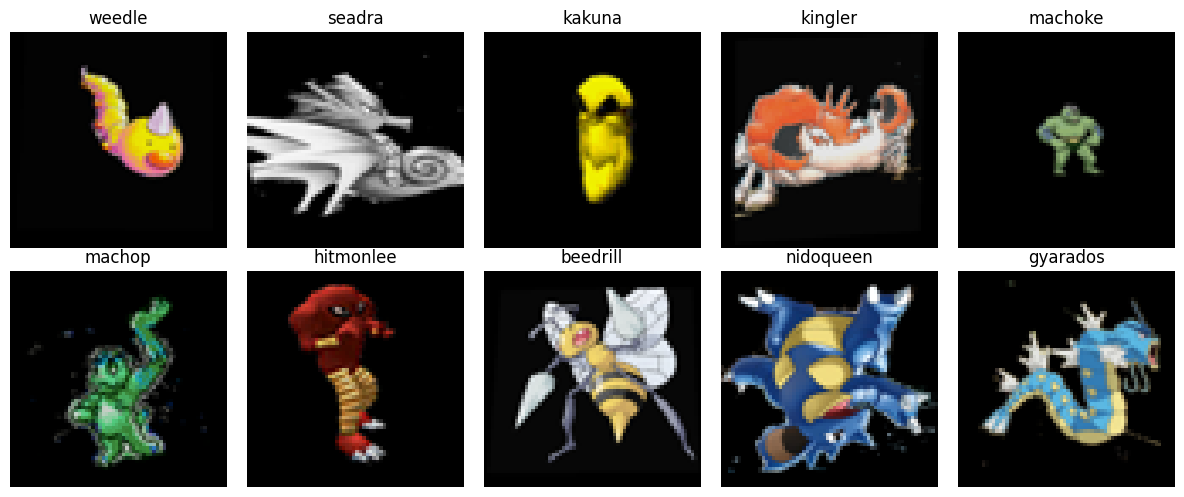

In [ ]:
def load_dataset(version="aug5"):
    base_path = f"Pokemon/{version}/"
    
    X_train = np.load(base_path + "X_train.npy")
    y_train = np.load(base_path + "y_train.npy")

    X_val = np.load(base_path + "X_val.npy")
    y_val = np.load(base_path + "y_val.npy")

    X_test = np.load(base_path + "X_test.npy")
    y_test = np.load(base_path + "y_test.npy")

    return X_train, y_train, X_val, y_val, X_test, y_test

# Get unique Pokémon names
class_names = np.unique(y_train)

print("Number of classes:", len(class_names))
print("Classes:", class_names)
plot_sample_images(X_train, y_train)

The dataset consists of multiple Pokémon classes, extracted from the label array. Each class corresponds to a unique Pokémon category used for classification.
Sample images were reconstructed from flattened arrays back into 64×64×3 format. Visualization confirmed that preprocessing preserved image structure and label integrity.

## Defined Datasets per experiments

In [97]:
# Experiment 1 (5 augmentations)
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset("aug5")

In [98]:
# Experiment 2 (10 augmentations)
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset("aug10")

In [99]:
def preprocess_data(X_train, X_val, X_test):
    
    # Normalize pixel values to [0, 1]
    X_train = X_train / 255.0
    X_val = X_val / 255.0
    X_test = X_test / 255.0
    
    # FLATTEN images
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_val = X_val.reshape(X_val.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)
    
    return X_train, X_val, X_test

In [100]:
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (39864, 12288)
Val shape: (1208, 12288)
Test shape: (1208, 12288)


## Build Neural Network

In [101]:
def create_model(input_dim, num_classes):
    
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        
        layers.Dense(512, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),

        layers.Dense(num_classes, activation='softmax')
    ])

#Compile
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

print(X_train.shape)
model = create_model(X_train.shape[1], len(np.unique(y_train)))
model.summary()

(39864, 12288)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_88 (Dense)                │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 151)            │        19,479 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,475,671 (24.70 MB)

 Trainable params: 6,475,671 (24.70 MB)

 Non-trainable params: 0 (0.00 B)

## Training per Experiment Function

In [109]:
def run_experiment(version):
    
    print(f"\n===== Running {version} Dataset =====")
    
    # Load data
    X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(version)

    # Convert string labels → integers
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_val = le.transform(y_val)
    y_test = le.transform(y_test)

    # Save class names in correct order
    class_names = le.classes_
    
    # Preprocess
    X_train, X_val, X_test = preprocess_data(X_train, X_val, X_test)    
    
    print("Train:", X_train.shape)
    
    # Create model
    model = create_model(X_train.shape[1], len(np.unique(y_train)))
    
    # Train
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=1
    )
    
    # Evaluate
    loss, acc = model.evaluate(X_test, y_test)
    
    return model, history, acc, X_test, y_test, class_names


## Run Experiments


Final Comparison:

===== Running aug5 Dataset =====
Train: (21744, 12288)
Epoch 1/10


c:\Users\Nyah Posey\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


680/680 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.0149 - loss: 4.8754 - val_accuracy: 0.0381 - val_loss: 4.4416
Epoch 2/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.0507 - loss: 4.3625 - val_accuracy: 0.0786 - val_loss: 4.0627
Epoch 3/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.0757 - loss: 4.1106 - val_accuracy: 0.0960 - val_loss: 3.9147
Epoch 4/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.0945 - loss: 3.9533 - val_accuracy: 0.1084 - val_loss: 3.7875
Epoch 5/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.1131 - loss: 3.8248 - val_accuracy: 0.1291 - val_loss: 3.7262
Epoch 6/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.1290 - loss: 3.7258 - val_accuracy: 0.1565 - val_loss: 3.6172
Epoch 7/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.1445 - loss: 3.6211 - val_accuracy: 0.1631 - val_loss: 3.5617
Epoch 8/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.1566 - loss: 3.5258 - val_accurac

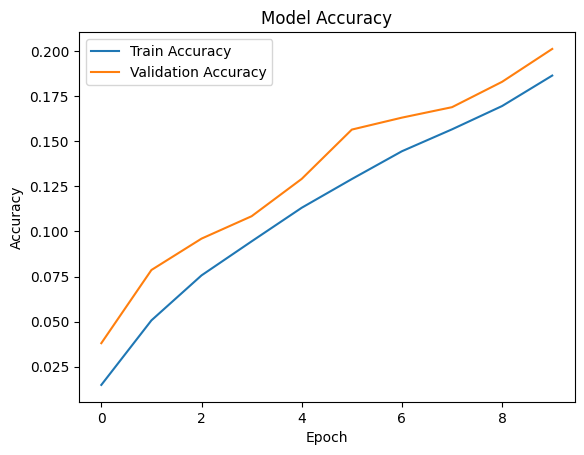

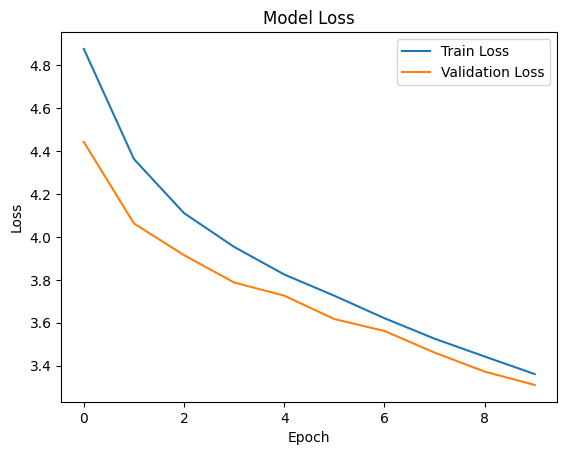

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


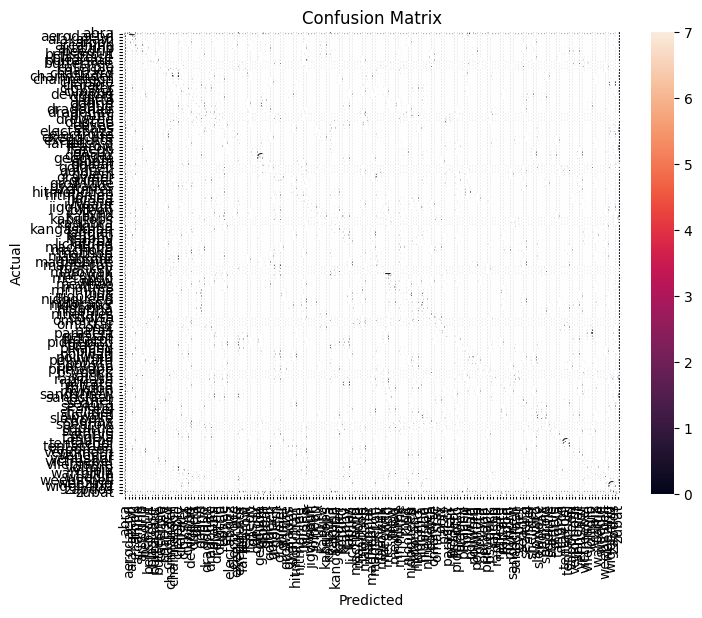

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.14      0.12      0.13         8
           1       0.36      0.62      0.45         8
           2       0.27      0.88      0.41         8
           3       0.40      0.25      0.31         8
           4       0.50      0.38      0.43         8
           5       0.43      0.38      0.40         8
           6       0.38      0.38      0.38         8
           7       0.33      0.25      0.29         8
           8       0.50      0.50      0.50         8
           9       0.20      0.12      0.15         8
          10       0.43      0.38      0.40         8
          11       0.00      0.00      0.00         8
          12       0.45      0.62      0.53         8
          13       0.25      0.25      0.25         8
          14       0.00      0.00      0.00         8
          15       0.18      0.50      0.27         8
          16       0.33      0.50      0.4

c:\Users\Nyah Posey\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nyah Posey\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nyah Posey\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Train: (39864, 12288)


c:\Users\Nyah Posey\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.0194 - loss: 4.7525 - val_accuracy: 0.0530 - val_loss: 4.2230
Epoch 2/10
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.0539 - loss: 4.2782 - val_accuracy: 0.1126 - val_loss: 3.8969
Epoch 3/10
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.0826 - loss: 4.0264 - val_accuracy: 0.1374 - val_loss: 3.6378
Epoch 4/10
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.1060 - loss: 3.8559 - val_accuracy: 0.1664 - val_loss: 3.4901
Epoch 5/10
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.1205 - loss: 3.7479 - val_accuracy: 0.1846 - val_loss: 3.3941
Epoch 6/10
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.1306 - loss: 3.6582 - val_accuracy: 0.1854 - val_loss: 3.3357
Epoch 7/10
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.1395 - loss: 3.5986 - val_accuracy: 0.1912 - val_loss: 3.3011
Epoch 8/10
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.1466 -

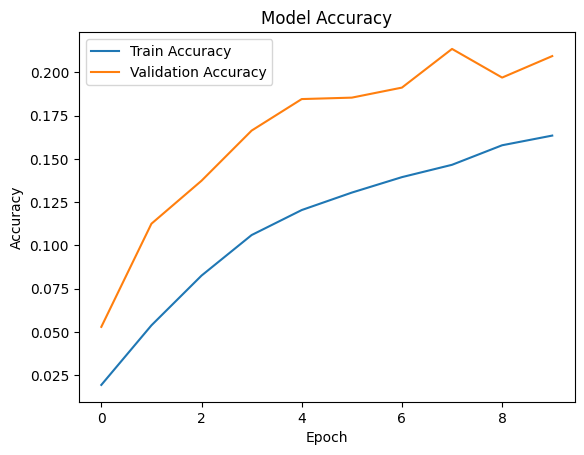

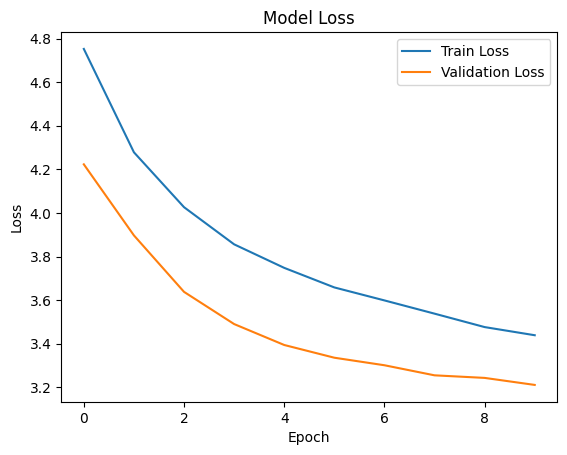

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


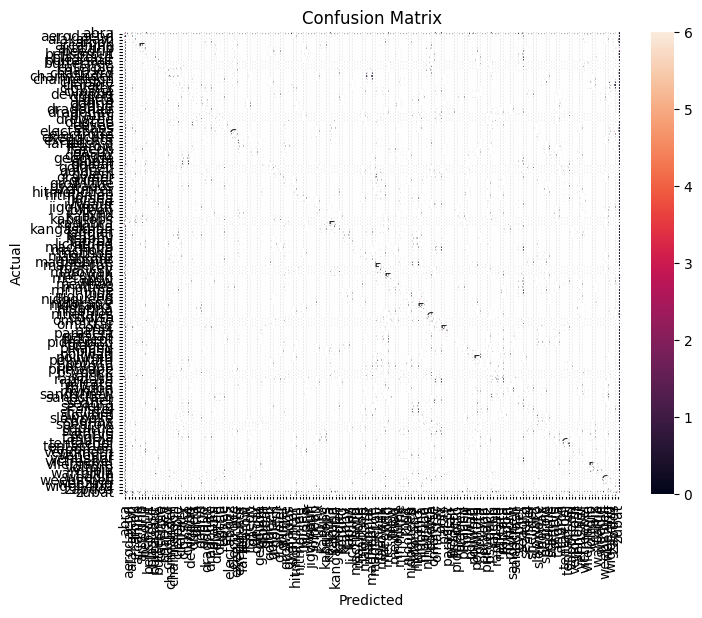

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.17      0.25      0.20         8
           1       0.36      0.50      0.42         8
           2       0.17      0.25      0.20         8
           3       0.20      0.38      0.26         8
           4       0.29      0.25      0.27         8
           5       0.22      0.62      0.32         8
           6       0.67      0.25      0.36         8
           7       0.20      0.38      0.26         8
           8       0.40      0.25      0.31         8
           9       0.38      0.38      0.38         8
          10       0.36      0.50      0.42         8
          11       0.00      0.00      0.00         8
          12       0.27      0.38      0.32         8
          13       1.00      0.25      0.40         8
          14       0.14      0.25      0.18         8
          15       0.23      0.38      0.29         8
          16       0.08      0.12      0.1

c:\Users\Nyah Posey\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nyah Posey\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nyah Posey\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [112]:
print("\nFinal Comparison:")
results = {}

for version in ["aug5", "aug10"]:
    model, history, acc, X_test, y_test, class_names = run_experiment(version)
    
    results[version] = {
        "test_accuracy": acc,
        "final_train_acc": history.history["accuracy"][-1],
        "final_val_acc": history.history["val_accuracy"][-1]
    }

    # PLOTS
    plot_training_history(history)
    plot_confusion_matrix(model, X_test, y_test, class_names)
    generate_classification_report(model, X_test, y_test)

In [113]:
for k, v in results.items():
    print("\n", k)
    print(v)


 aug5
{'test_accuracy': 0.22847682237625122, 'final_train_acc': 0.18639624118804932, 'final_val_acc': 0.20115894079208374}

 aug10
{'test_accuracy': 0.21937085688114166, 'final_train_acc': 0.1635059267282486, 'final_val_acc': 0.20943708717823029}


In [114]:
print("Class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for i, count in zip(unique, counts):
    print(class_names[i], count)

Class distribution:
abra 8
aerodactyl 8
alakazam 8
arbok 8
arcanine 8
articuno 8
beedrill 8
bellsprout 8
blastoise 8
bulbasaur 8
butterfree 8
caterpie 8
chansey 8
charizard 8
charmander 8
charmeleon 8
clefable 8
clefairy 8
cloyster 8
cubone 8
dewgong 8
diglett 8
ditto 8
dodrio 8
doduo 8
dragonair 8
dragonite 8
dratini 8
drowzee 8
dugtrio 8
eevee 8
ekans 8
electabuzz 8
electrode 8
exeggcute 8
exeggutor 8
farfetch'd 8
fearow 8
flareon 8
gastly 8
gengar 8
geodude 8
gloom 8
golbat 8
goldeen 8
golduck 8
golem 8
graveler 8
grimer 8
growlithe 8
gyarados 8
haunter 8
hitmonchan 8
hitmonlee 8
horsea 8
hypno 8
ivysaur 8
jigglypuff 8
jolteon 8
jynx 8
kabuto 8
kabutops 8
kadabra 8
kakuna 8
kangaskhan 8
kingler 8
koffing 8
krabby 8
lapras 8
lickitung 8
machamp 8
machoke 8
machop 8
magikarp 8
magmar 8
magnemite 8
magneton 8
mankey 8
marowak 8
meowth 8
metapod 8
mew 8
mewtwo 8
moltres 8
mr mime 8
muk 8
nidoking 8
nidoqueen 8
nidoran♀ 8
nidoran♂ 8
nidorina 8
nidorino 8
ninetales 8
oddish 8
omanyte 8
om

The model was evaluated using accuracy, classification report, and confusion matrix. Accuracy provides an overall measure of correctness, while precision, recall, and F1-score give class-level performance insights.

A confusion matrix was used to visualize misclassifications between Pokémon classes. Additionally, reconstructed sample images confirmed that preprocessing steps preserved image quality and labels.

Training and validation curves were analyzed to assess model learning behavior and detect overfitting.